# State Estimation with Physics-Encoded Neural Network 

Using a Context-Aware DeLaN model with log-Cholesky decomposition for inertia matrix and torque biases estimation, and residual torque prediction. Use inertia matrix and torque biases in Kalman Filter for state estimation

Currently working with simulated data by `mpx`.

In [1]:
%load_ext autoreload
%autoreload 2

### Evaluate model with all runs in a dataset

In [ ]:
from felan.train import load_model_fn
from pathlib import Path
from utils.evaluate import _nominal_trunk_mass

model_name = "epochs_1000_quad_mass_dataset_run8_input_values_joint_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_0"
cadelac_path = Path(f"trained_models/LogChol-CaDeLaC/LogChol-CaDeLaC/{model_name}")
params, hyper = load_model_fn(cadelac_path.name, cadelac_path.parent)

test = {"key": "value"}
test.update()

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


13.042

In [ ]:
from utils.evaluate import evaluate_dataset, print_report
from pathlib import Path

dataset_num = 8
dataset_path = Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz"
model_name = "epochs_1000_quad_mass_dataset_run8_input_values_joint_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_0"
cadelac_path = Path(f"trained_models/LogChol-CaDeLaC/LogChol-CaDeLaC/{model_name}")

res = evaluate_dataset(dataset_path, cadelac_path)
print_report(res)

In [9]:
from pathlib import Path
from utils.kf_utils import load_custom_dataset
from utils.run_estimation import run_state_estimation
from utils.plot_data import *

sim_num = 11
dataset_num = 8
data = load_custom_dataset(
    dataset_path=Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz", 
    sim_num=sim_num)

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.


In [8]:
from utils.evaluate import evaluate_dataset, print_report

dataset_num = 8
dataset_path = Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz"
model_name = "epochs_1000_quad_mass_dataset_run8_input_values_joint_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_0"
cadelac_path = Path(f"trained_models/LogChol-CaDeLaC/LogChol-CaDeLaC/{model_name}")

res = evaluate_dataset(dataset_path, cadelac_path)
print_report(res)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
  sim  0 [test ] dm  3.203 /  3.185 (+0.018)   vel RMSE [0.026 0.011 0.306]
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)
  sim  1 [test ] dm  3.160 /  3.185 (-0.025)   vel RMSE [0.011 0.01  0.168]
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.
Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loadi

# With CaDeLaC

In [10]:
tau = (data["tau_m"]+data["tau_c"]+data["tau_g"])[..., :6]
tau_nom = (data["tau_m_nom"]+data["tau_c_nom"]+data["tau_g_nom"])[..., :6]
model_name = "epochs_1000_quad_mass_dataset_run8_input_values_joint_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_0"
cadelac_path = Path(f"trained_models/LogChol-CaDeLaC/LogChol-CaDeLaC/{model_name}")

result = run_state_estimation(
    dt=data["dt"][0],
    base_orient=data["base_orient"],
    base_ang_vel=data["base_ang_vel"],
    joint_pos=data["joint_pos"],
    joint_vel=data["joint_vel"],
    joint_acc=data["joint_acc"],
    joint_torque=data["joint_torque"],
    # contact_states=data["contact_states"],   # empfohlen: explizit angeben (siehe Hinweis unten)
    # base_pos=data["base_pos"],               # nötig für CaDeLaCs Feature-Vektor (base_pos_z)
    # base_vel=data["base_vel"],               # nötig für CaDeLaCs Feature-Vektor
    # Q=[0.0001, 0.0001, 0.0001, 0.001],
    # R=[0.1, 0.1, 0.0001, 0.01],
    Q=[1e-4,1e-4,1e-4,4.0], 
    R=[0.1,6e-3,1e-4,1000],
    est_mode=4,
    cadelac_path=cadelac_path,
    tau=tau,
    tau_nominal=tau_nom
)

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)


In [67]:
import numpy as np
from gym_quadruped.quadruped_env import QuadrupedEnv

M_mj = np.asarray(result["inertia_matrix"]["mujoco"])   # (N,6,6) nominal
M_cd = np.asarray(result["inertia_matrix"]["cadelac"])  # (N,6,6) nominal + Residuum
q_mj = np.asarray(result["qfrc_bias"]["mujoco"])        # (N,6)
q_cd = np.asarray(result["qfrc_bias"]["cadelac"])       # (N,6)

dM_est = M_cd - M_mj                                                 # geschätztes Inertia-Residuum
dq_est = q_cd - q_mj                                                 # geschätztes Bias-Residuum
dq_gt  = (data["diff_tau_c_nom"] + data["diff_tau_g_nom"])[:, :6]    # wahres Bias-Residuum

m_trunk_nom = float(QuadrupedEnv(robot="aliengo").mjModel.body_mass[1])   # 13.042 kg
dm_true = float(data["base_mass"][0] - m_trunk_nom)
dm_est  = dM_est[:, 0, 0]

print(f"Zusatzmasse : {dm_est.mean():6.3f} +- {dm_est.std():.3f} kg   "
      f"wahr {dm_true:.3f} kg   Fehler {dm_est.mean()-dm_true:+.3f} kg "
      f"({abs(dm_est.mean()-dm_true)/dm_true:.1%})")

lbl = ["f_x", "f_y", "f_z", "tau_roll", "tau_pitch", "tau_yaw"]
print("\nqfrc_bias-Residuum        wahr    geschätzt      RMSE")
for i, n in enumerate(lbl):
    print(f"  {n:10s} {np.abs(dq_gt[:,i]).mean():10.3f} {np.abs(dq_est[:,i]).mean():12.3f} "
          f"{np.sqrt(((dq_est[:,i]-dq_gt[:,i])**2).mean()):9.3f}")

print("\nInertia-Residuum, mean |dM|:")
print(np.round(np.abs(dM_est).mean(axis=0), 3))


Zusatzmasse :  4.940 +- 0.184 kg   wahr 4.986 kg   Fehler -0.046 kg (0.9%)

qfrc_bias-Residuum        wahr    geschätzt      RMSE
  f_x             0.023        0.027     0.013
  f_y             0.035        0.035     0.009
  f_z            48.920       48.470     1.863
  tau_roll        0.376        0.393     0.093
  tau_pitch       1.981        2.000     0.248
  tau_yaw         0.011        0.001     0.013

Inertia-Residuum, mean |dM|:
[[4.94e+00 0.00e+00 0.00e+00 0.00e+00 1.43e-01 4.00e-02]
 [0.00e+00 4.94e+00 0.00e+00 1.43e-01 0.00e+00 2.04e-01]
 [0.00e+00 0.00e+00 4.94e+00 4.00e-02 2.04e-01 0.00e+00]
 [0.00e+00 1.43e-01 4.00e-02 3.90e-02 6.00e-03 4.00e-03]
 [1.43e-01 0.00e+00 2.04e-01 6.00e-03 2.70e-02 1.00e-03]
 [4.00e-02 2.04e-01 0.00e+00 4.00e-03 1.00e-03 3.10e-02]]


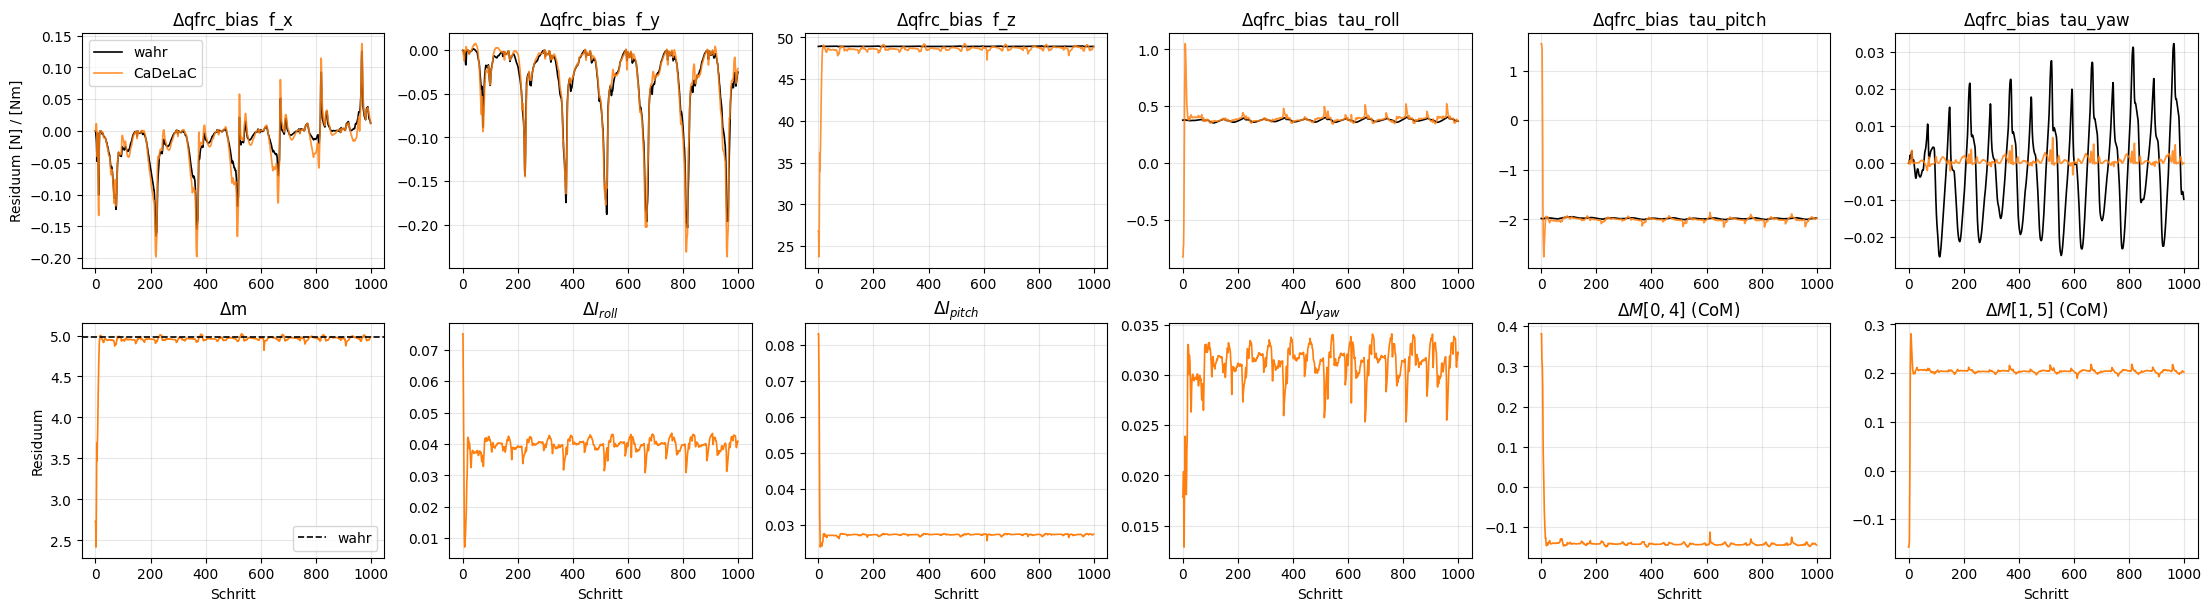

In [68]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(22, 6), constrained_layout=True)

for i in range(6):                                   # oben: Bias-Residuum gegen Wahrheit
    ax = axes[0, i]
    ax.plot(dq_gt[:, i],  label="wahr",    color="k",          lw=1.2)
    ax.plot(dq_est[:, i], label="CaDeLaC", color="tab:orange", lw=1.2, alpha=.85)
    ax.set_title(f"$\\Delta$qfrc_bias  {lbl[i]}")
    ax.grid(alpha=.3)
    if i == 0:
        ax.legend(); ax.set_ylabel("Residuum [N] / [Nm]")

pairs = [(0,0,"$\\Delta$m"), (3,3,"$\\Delta I_{roll}$"), (4,4,"$\\Delta I_{pitch}$"),
         (5,5,"$\\Delta I_{yaw}$"), (0,4,"$\\Delta M[0,4]$ (CoM)"), (1,5,"$\\Delta M[1,5]$ (CoM)")]
for k, (a, b, name) in enumerate(pairs):             # unten: Inertia-Residuum, muss konstant sein
    ax = axes[1, k]
    ax.plot(dM_est[:, a, b], color="tab:orange", lw=1.2)
    if (a, b) == (0, 0):
        ax.axhline(dm_true, color="k", ls="--", lw=1.2, label="wahr")
        ax.legend(); ax.set_ylabel("Residuum")
    ax.set_title(name); ax.set_xlabel("Schritt"); ax.grid(alpha=.3)

plt.show()


In [51]:
import jax.numpy as jnp

M_mujoco_all, M_cadelac_all = result["inertia_matrix"]["mujoco"], result["inertia_matrix"]["cadelac"]
qfrc_mujoco_all, qfrc_cadelac_all = result["qfrc_bias"]["mujoco"], result["qfrc_bias"]["cadelac"]

M_mj = jnp.stack(M_mujoco_all)      # (N, 6, 6)
M_cd = jnp.stack(M_cadelac_all)      # (N, 6, 6)
qfrc_mj = jnp.stack(qfrc_mujoco_all)  # (N, 6)
qfrc_cd = jnp.stack(qfrc_cadelac_all) # (N, 6)

# Diagonal-Elemente separat (die sind physikalisch am wichtigsten)
M_diag_mj = jnp.diagonal(M_mj, axis1=1, axis2=2)  # (N, 6)
M_diag_cd = jnp.diagonal(M_cd, axis1=1, axis2=2)

# Relative Fehler pro Diagonalelement
rel_err_M = jnp.abs(M_diag_cd - M_diag_mj) / (jnp.abs(M_diag_mj) + 1e-6)
rel_err_qfrc = jnp.abs(qfrc_cd - qfrc_mj) / (jnp.abs(qfrc_mj) + 1e-6)

print("=== Inertia Matrix (Diagonal) ===")
for i, name in enumerate(["m_x", "m_y", "m_z", "I_roll", "I_pitch", "I_yaw"]):
    print(f"{name:8s}: MuJoCo mean={M_diag_mj[:, i].mean():.4f}, "
          f"CaDeLaC mean={M_diag_cd[:, i].mean():.4f}, "
          f"rel_err mean={rel_err_M[:, i].mean():.2%}, "
          f"max={rel_err_M[:, i].max():.2%}")

print("\n=== qfrc_bias ===")
for i, name in enumerate(["f_x", "f_y", "f_z", "tau_roll", "tau_pitch", "tau_yaw"]):
    print(f"{name:9s}: MuJoCo mean={qfrc_mj[:, i].mean():.4f}, "
          f"CaDeLaC mean={qfrc_cd[:, i].mean():.4f}, "
          f"rel_err mean={rel_err_qfrc[:, i].mean():.2%}, "
          f"max={rel_err_qfrc[:, i].max():.2%}")

# Frobenius-Norm der Off-Diagonal-Kopplungen (sollten bei einer starren Basis ~0 sein)
M_offdiag_mj_norm = jnp.linalg.norm(M_mj - jnp.diagonal(M_mj, axis1=1, axis2=2)[:, :, None] * jnp.eye(6), axis=(1,2))
M_offdiag_cd_norm = jnp.linalg.norm(M_cd - jnp.diagonal(M_cd, axis1=1, axis2=2)[:, :, None] * jnp.eye(6), axis=(1,2))
print(f"\nOff-Diagonal Norm: MuJoCo mean={M_offdiag_mj_norm.mean():.4f}, "
      f"CaDeLaC mean={M_offdiag_cd_norm.mean():.4f}")

=== Inertia Matrix (Diagonal) ===
m_x     : MuJoCo mean=24.6380, CaDeLaC mean=27.8745, rel_err mean=13.14%, max=18.13%
m_y     : MuJoCo mean=24.6380, CaDeLaC mean=27.8745, rel_err mean=13.14%, max=18.13%
m_z     : MuJoCo mean=24.6380, CaDeLaC mean=27.8745, rel_err mean=13.14%, max=18.13%
I_roll  : MuJoCo mean=0.2478, CaDeLaC mean=0.2758, rel_err mean=11.33%, max=22.95%
I_pitch : MuJoCo mean=0.9036, CaDeLaC mean=0.9407, rel_err mean=4.11%, max=7.34%
I_yaw   : MuJoCo mean=0.9426, CaDeLaC mean=0.9536, rel_err mean=1.17%, max=7.48%

=== qfrc_bias ===
f_x      : MuJoCo mean=2.1031, CaDeLaC mean=2.0932, rel_err mean=21.28%, max=3725.49%
f_y      : MuJoCo mean=1.0906, CaDeLaC mean=1.0558, rel_err mean=28.31%, max=6047.89%
f_z      : MuJoCo mean=245.1928, CaDeLaC mean=276.8940, rel_err mean=12.93%, max=17.39%
tau_roll : MuJoCo mean=0.4385, CaDeLaC mean=0.7607, rel_err mean=181.96%, max=38000.42%
tau_pitch: MuJoCo mean=1.0095, CaDeLaC mean=-0.6183, rel_err mean=292.14%, max=20512.96%
tau_yaw  :

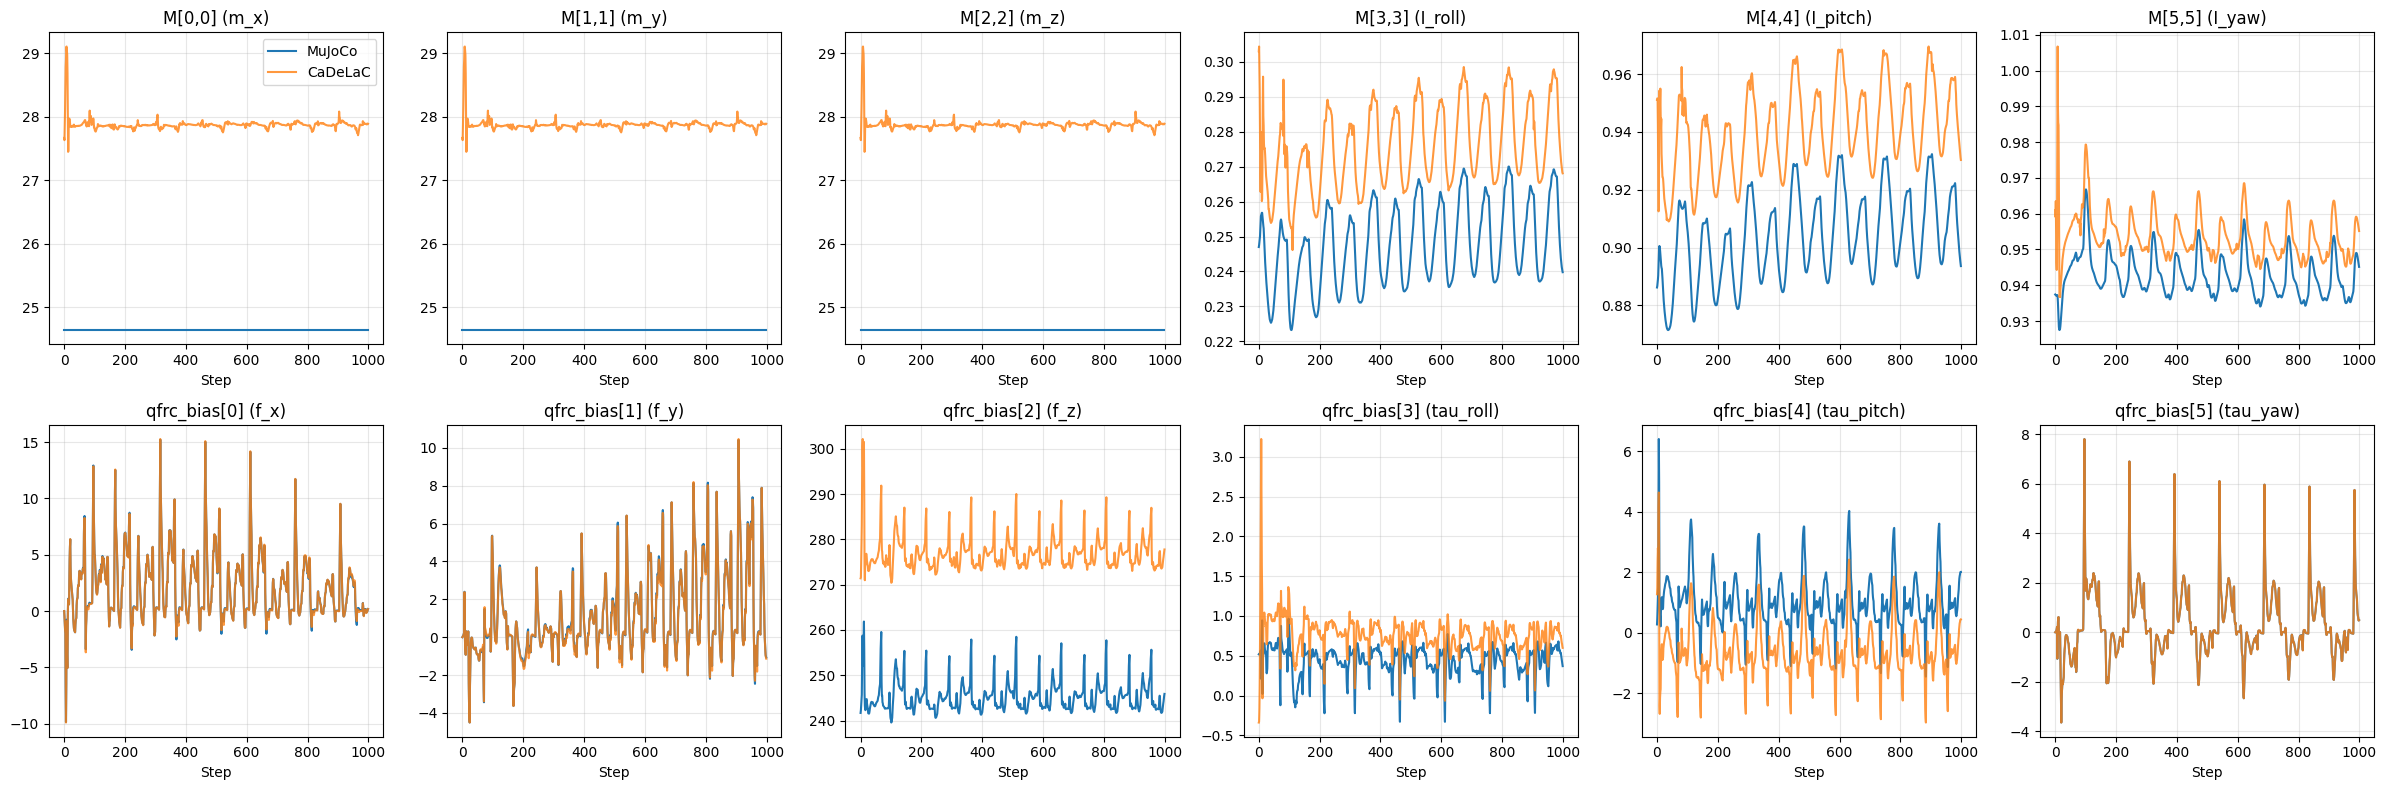

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(24, 8))
diag_labels = ["m_x", "m_y", "m_z", "I_roll", "I_pitch", "I_yaw"]
qfrc_labels = ["f_x", "f_y", "f_z", "tau_roll", "tau_pitch", "tau_yaw"]

# Obere Reihe: Inertia-Diagonalen
for i in range(6):
    ax = axes[0, i]
    ax.plot(M_diag_mj[:, i], label="MuJoCo", color="tab:blue", linewidth=1.5)
    ax.plot(M_diag_cd[:, i], label="CaDeLaC", color="tab:orange", linewidth=1.5, alpha=0.8)
    ax.set_title(f"M[{i},{i}] ({diag_labels[i]})")
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend()

# Untere Reihe: qfrc_bias-Komponenten
for i in range(6):
    ax = axes[1, i]
    ax.plot(qfrc_mj[:, i], label="MuJoCo", color="tab:blue", linewidth=1.5)
    ax.plot(qfrc_cd[:, i], label="CaDeLaC", color="tab:orange", linewidth=1.5, alpha=0.8)
    ax.set_title(f"qfrc_bias[{i}] ({qfrc_labels[i]})")
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("cadelac_vs_mujoco.png", dpi=100)
plt.show()

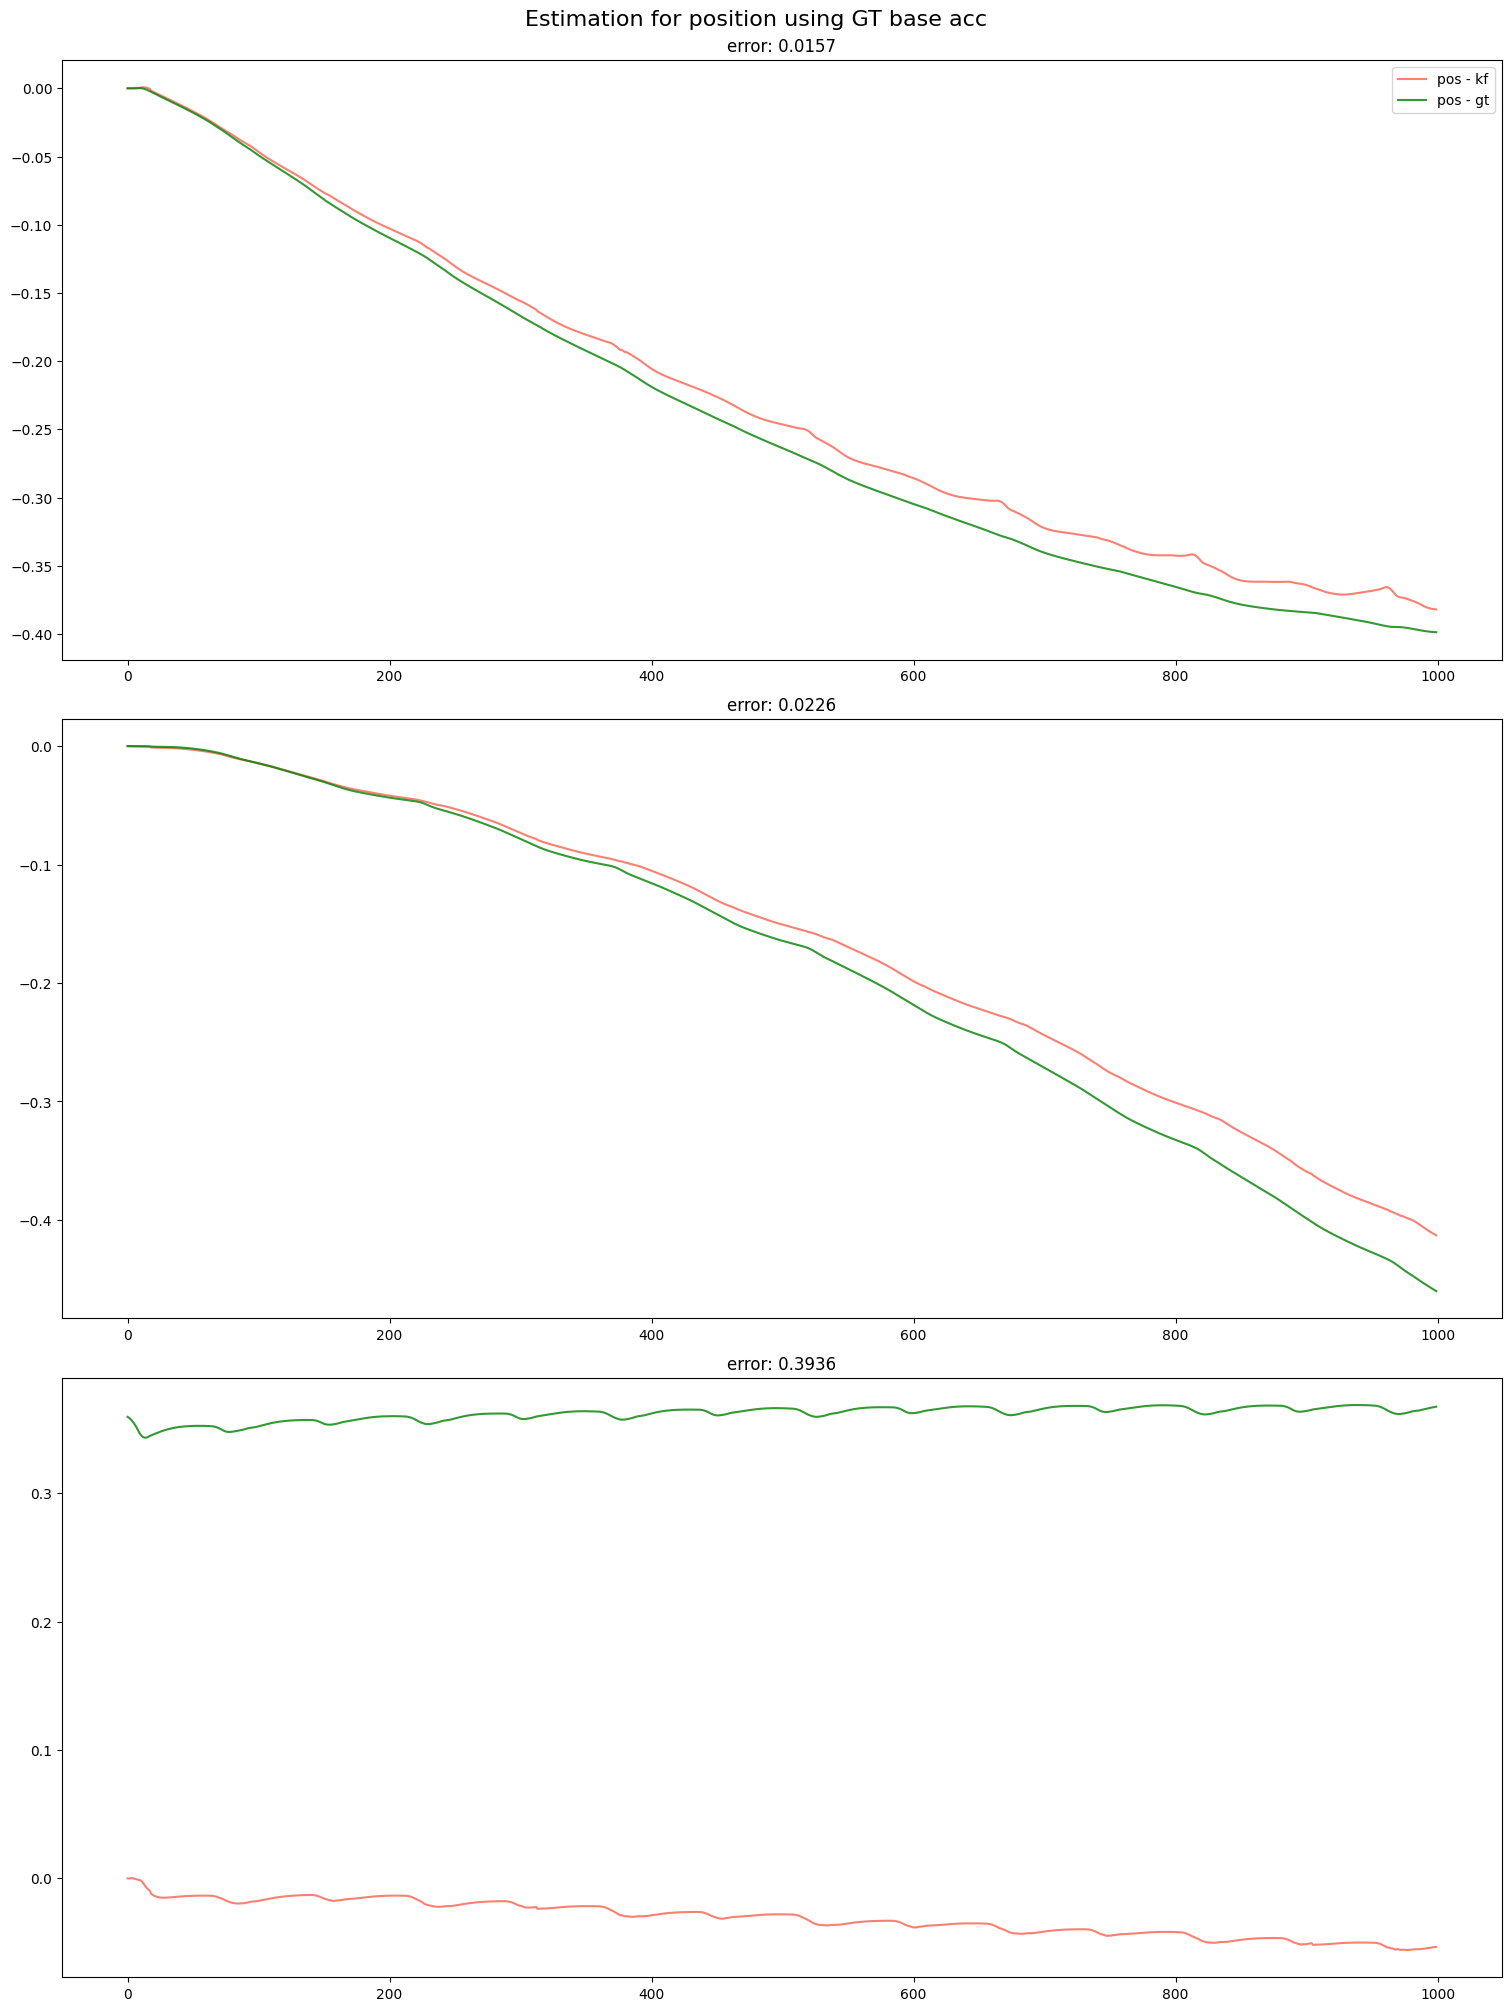

In [11]:
estimation_plot(gt_value=data["base_pos"],
                est_value=result["pos_update"],
                label="pos",
                title="Estimation for position using GT base acc")

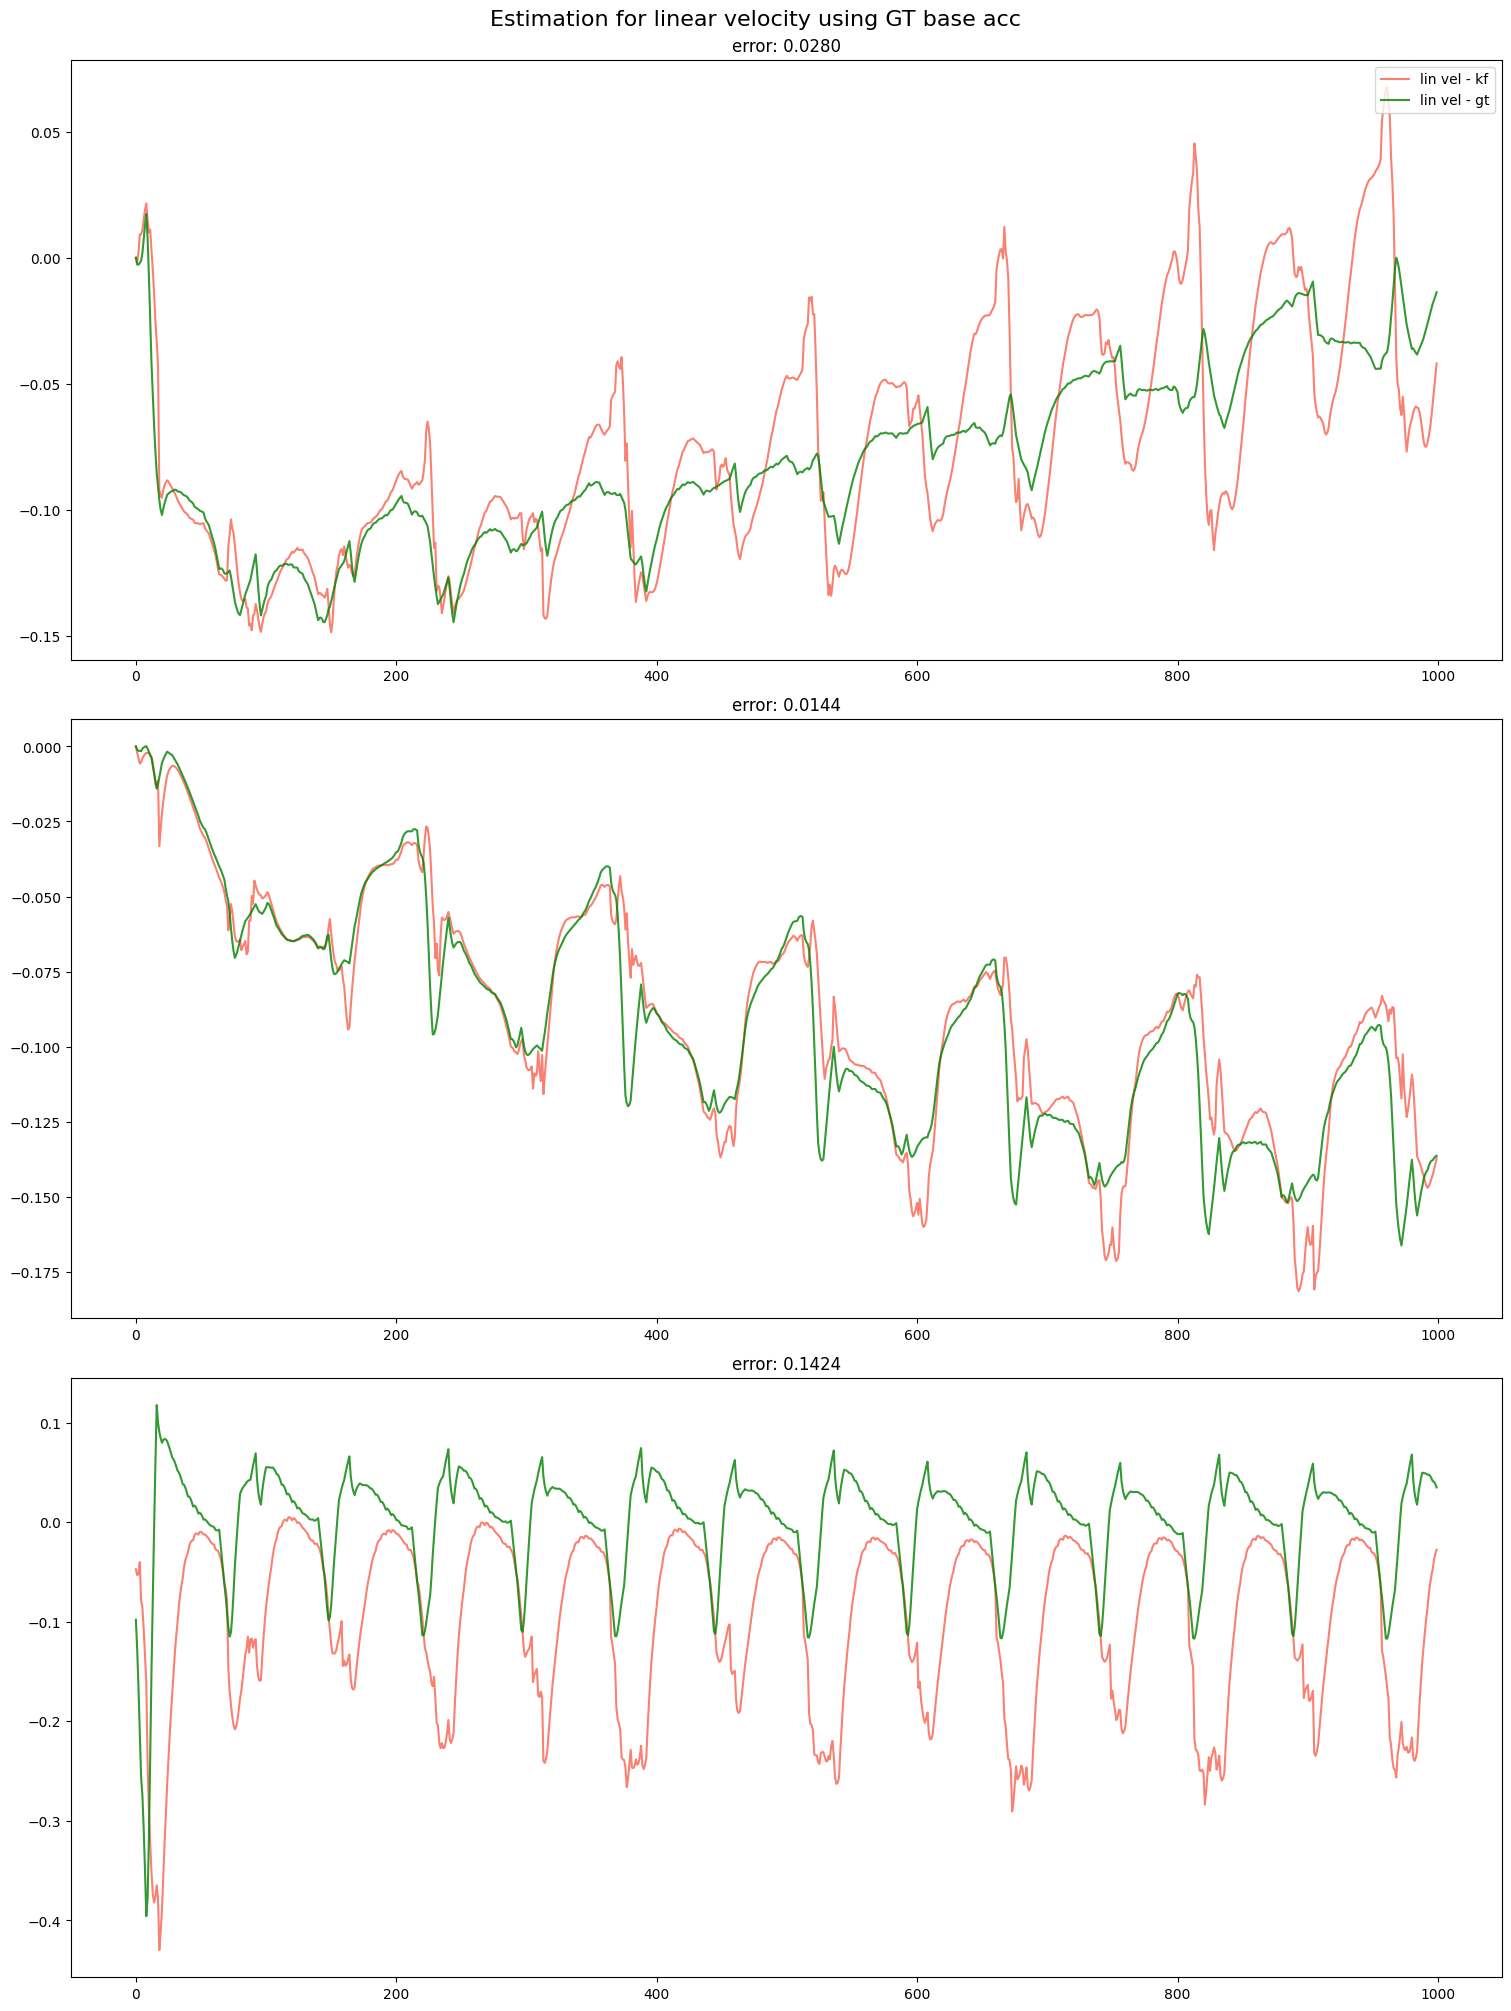

In [12]:
estimation_plot(gt_value=data["base_vel"],
                est_value=result["vel_update"],
                label="lin vel",
                title="Estimation for linear velocity using GT base acc")

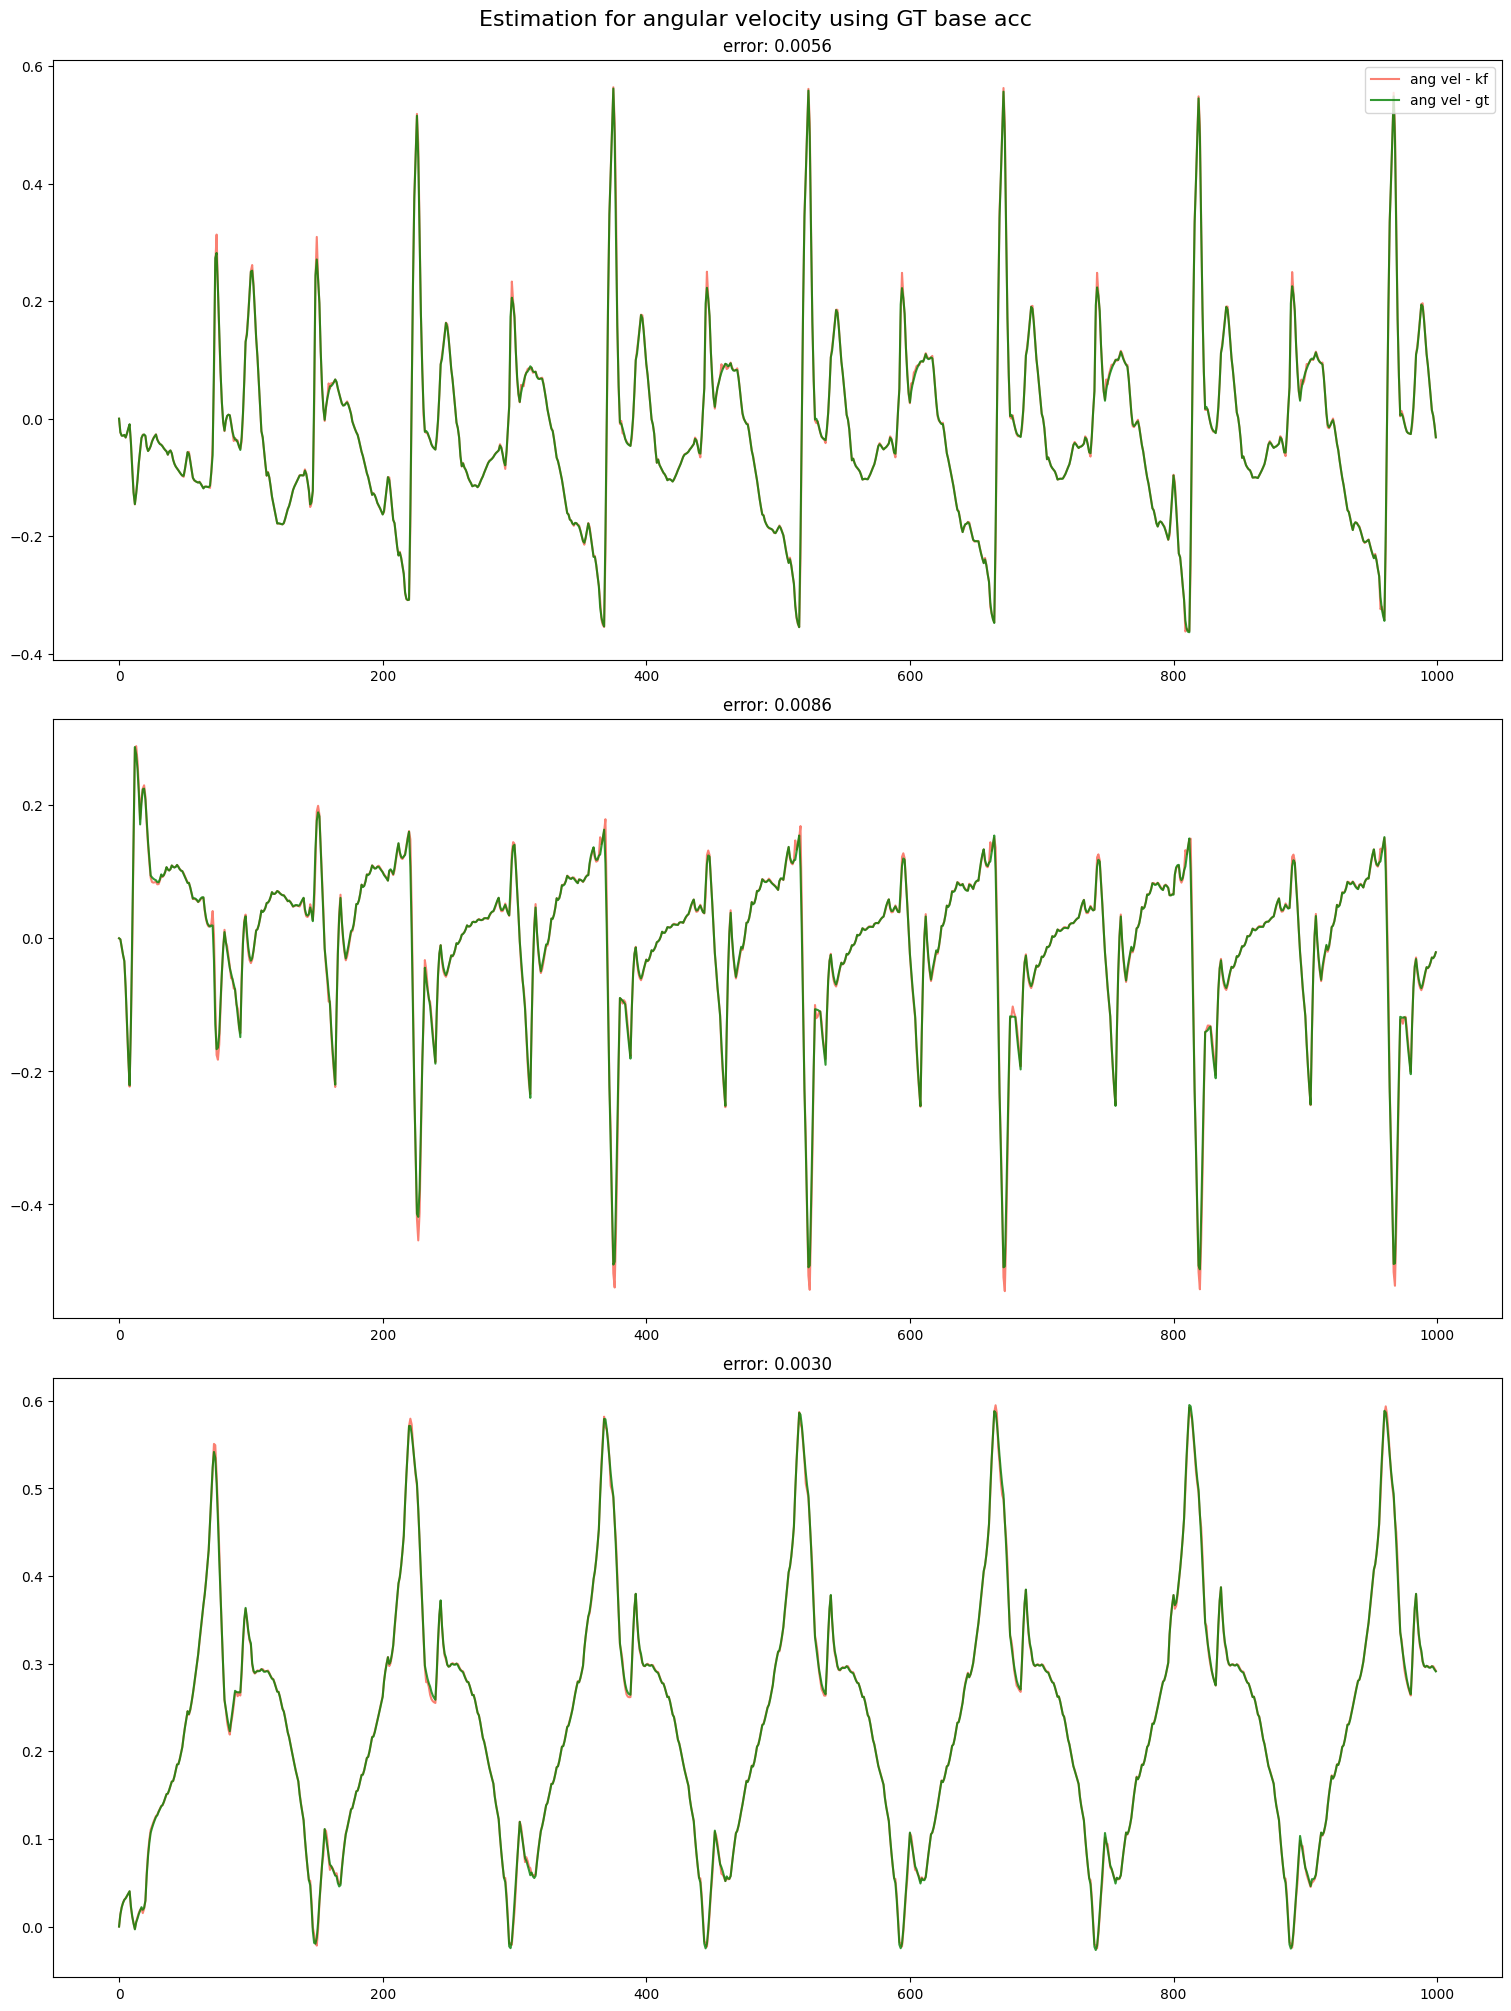

In [13]:
estimation_plot(gt_value=data["base_ang_vel"],
                est_value=result["ang_vel_update"],
                label="ang vel",
                title="Estimation for angular velocity using GT base acc")

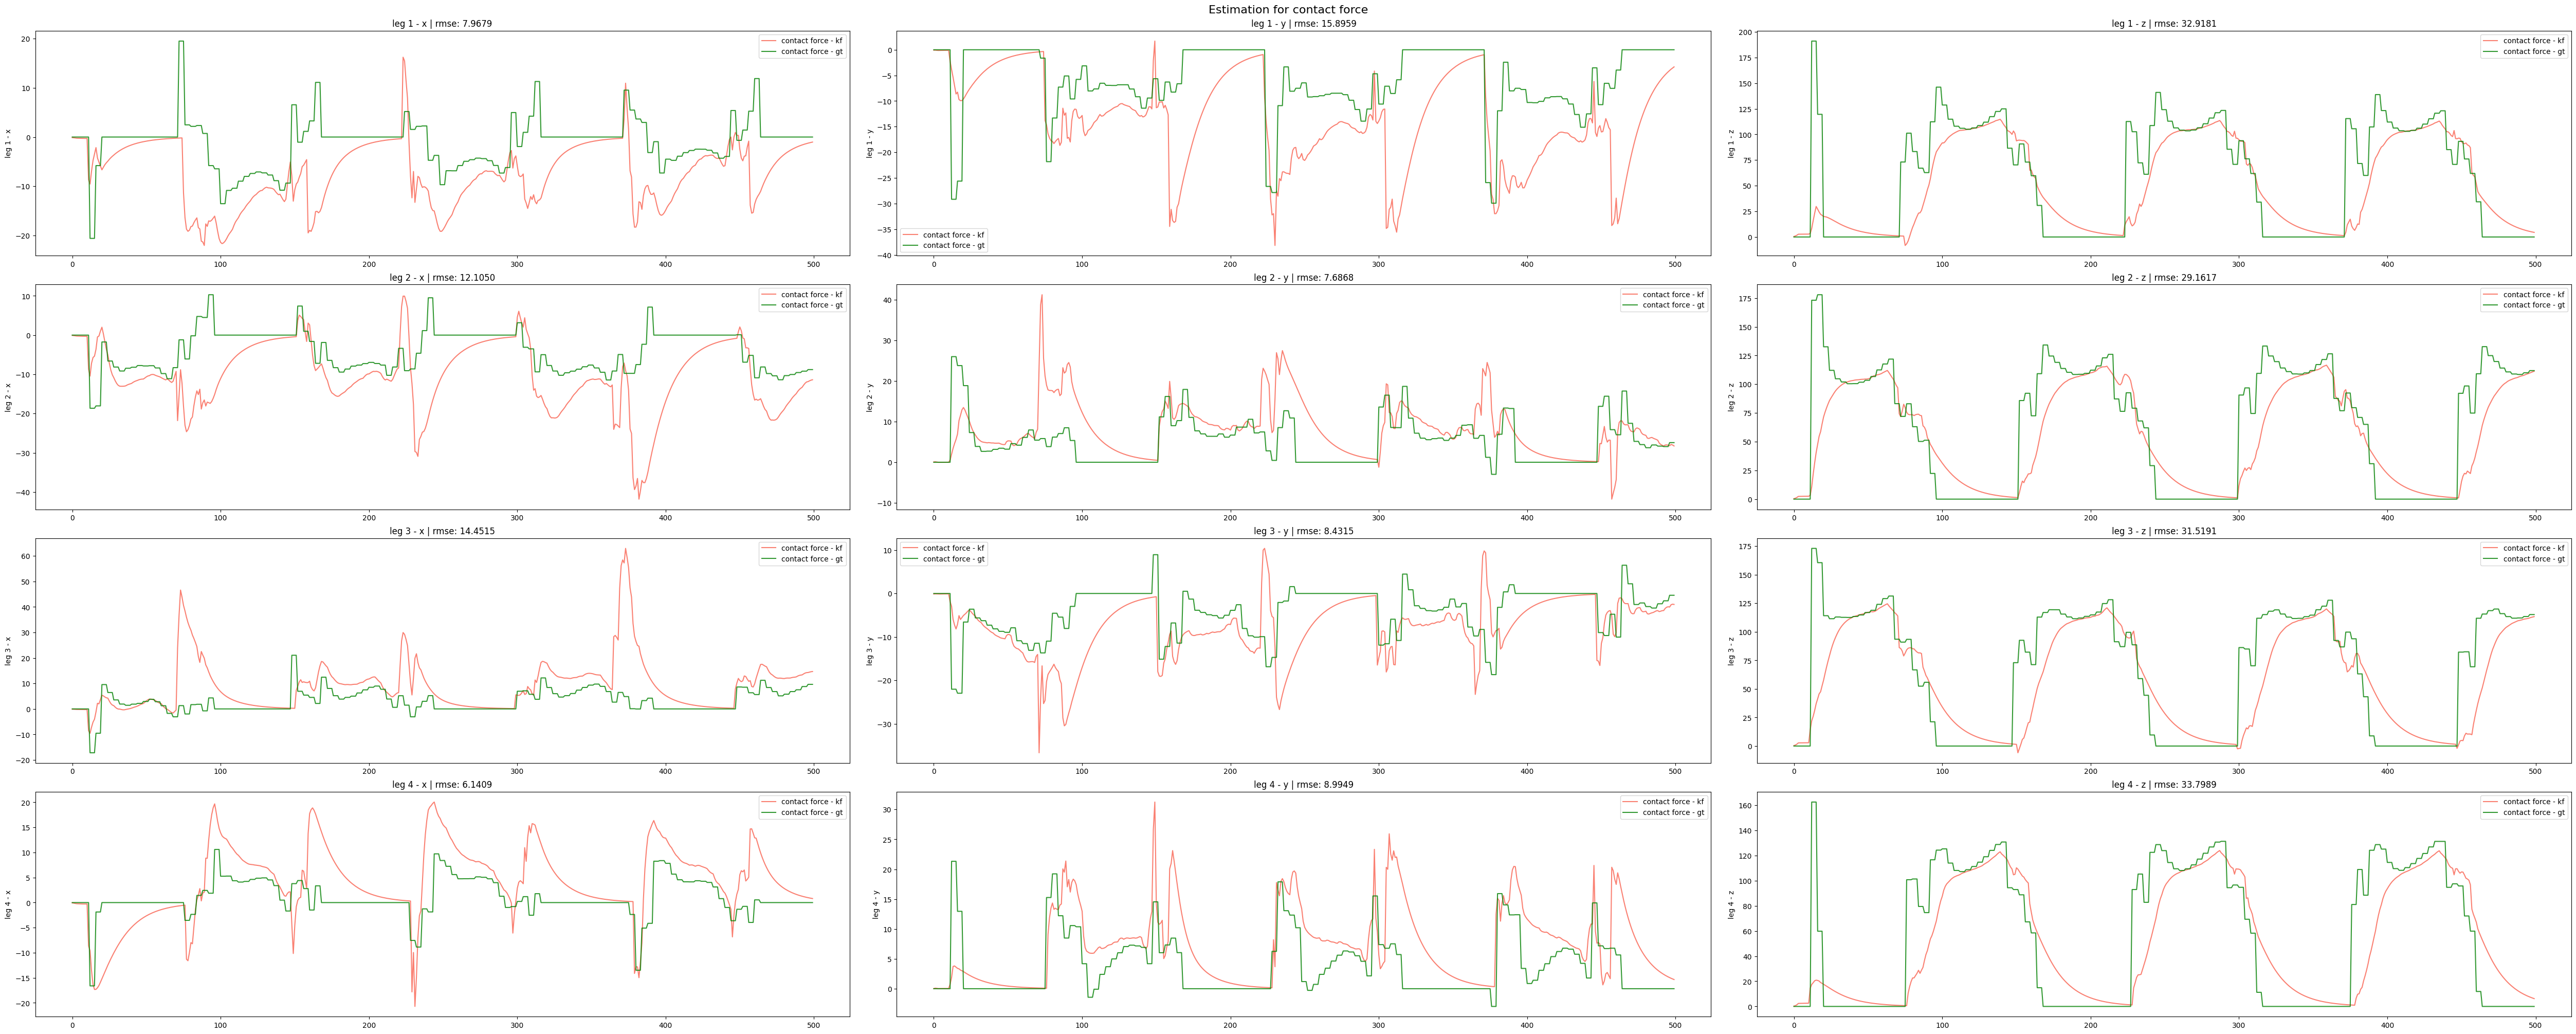

In [14]:
force_estimation_plot(gt_value=data["contact_forces"],
                      est_value=result["c_force_update"],
                      label="contact force",
                      start=0,
                      end=500,
                      title="Estimation for contact force")

# Report-Auswertung: Vergleichsleiter

Vier Stufen, identisches Q/R, `est_mode 4`, online-realistisch (keine Ground Truth an den Filter):

1. **Leg-Odometrie roh** — untere Referenz ohne Filter
2. **KF + Nominalmodell** — Baseline: was der Filter ohne gelerntes Modell kann
3. **KF + CaDeLaC** — der eigentliche Ansatz
4. **KF + Oracle** — wahre Residuen (Δm aus `base_mass`, `diff_tau_c_nom + diff_tau_g_nom` als Bias) statt Netz: die Obergrenze dessen, was ein *perfektes* Netz dem Filter bringen kann

Interpretation: (3)−(2) = Nutzen des Netzes, (4)−(2) = maximal möglicher Nutzen besserer Dynamik, (4)−(3) = Verlust durch Netzfehler. Liegt (4) ≈ (2), kann der KF von besserer Dynamik prinzipiell nicht profitieren — dann liegt der Engpass im Filter selbst, nicht im Modell.

In [1]:
from pathlib import Path
from utils.kf_utils import load_custom_dataset
from utils.report_plots import (run_ladder_for_sim, plot_state_comparison, evaluate_ladder,
                                ladder_summary, plot_ladder_bars, plot_mass_scatter,
                                plot_tau_improvement)

dataset_num = 8
dataset_path = Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz"
model_name = "epochs_1000_quad_mass_dataset_run8_input_values_base_pos_z_16-16_lstm5x10_wd1e-05_span0.5s-stride4-gap10_seed_0"
cadelac_path = Path(f"trained_models/LogChol-CaDeLaC/LogChol-CaDeLaC/{model_name}")
fig_dir = Path("figures/report") / model_name   # alle Report-Plots landen hier (.png + .pdf)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.


Running state estimation:   8%|▊         | 85/1000 [00:00<00:01, 841.87it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1191.82it/s]


Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)


Running state estimation:  10%|█         | 105/1000 [00:00<00:00, 1041.20it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1099.43it/s]


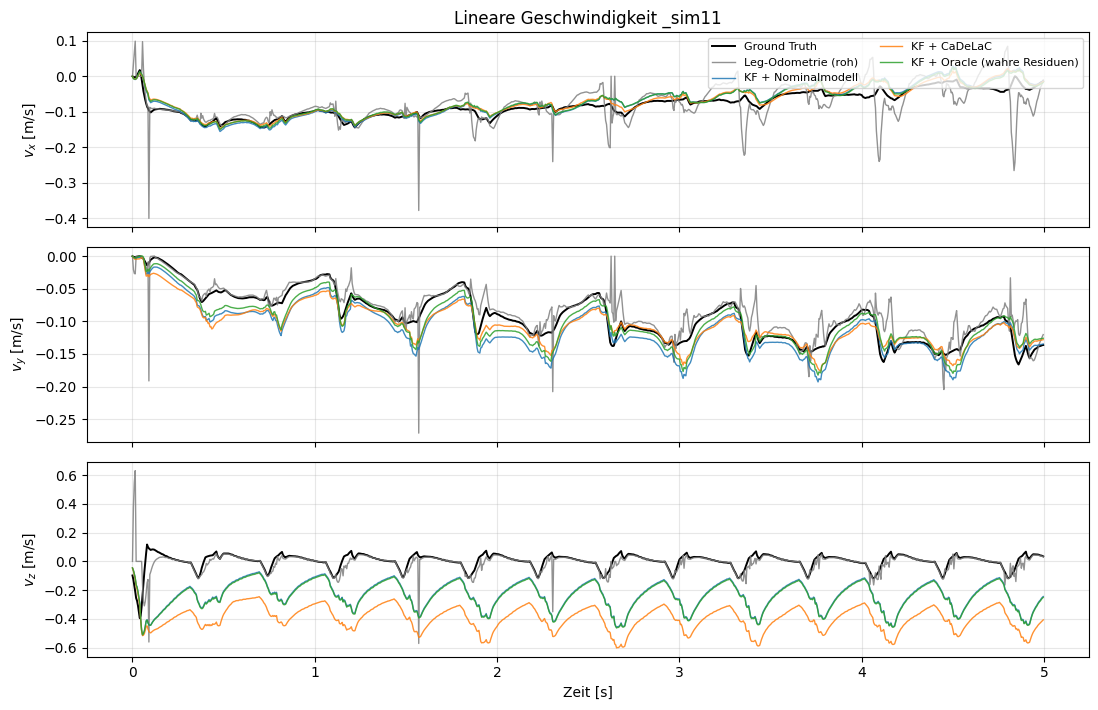

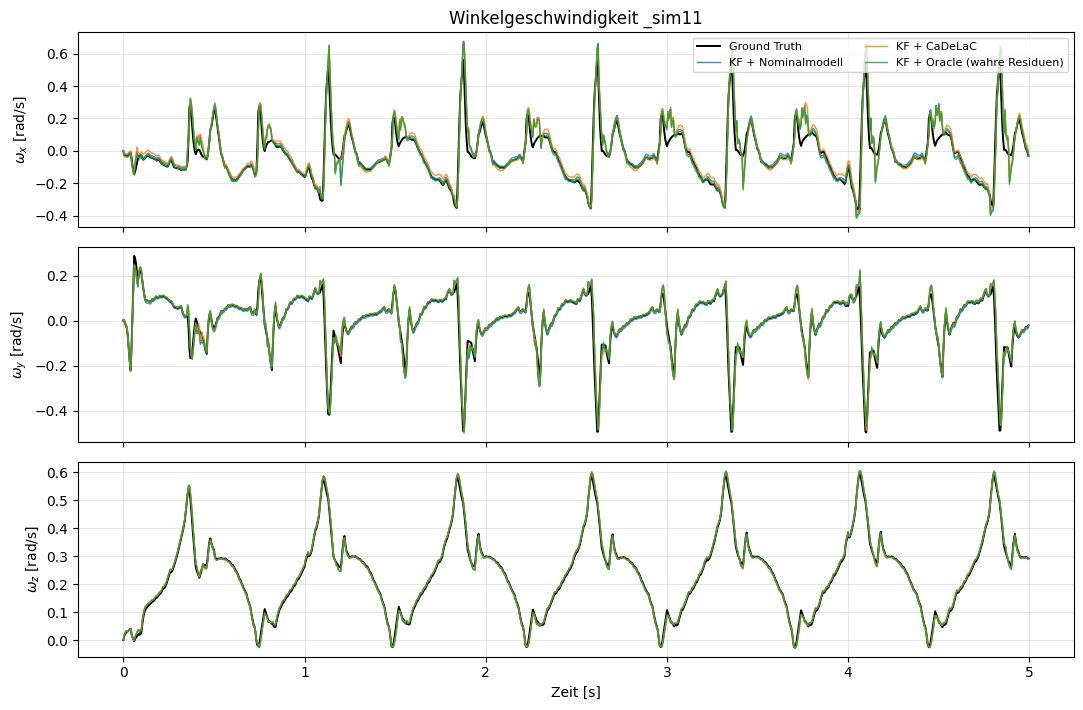

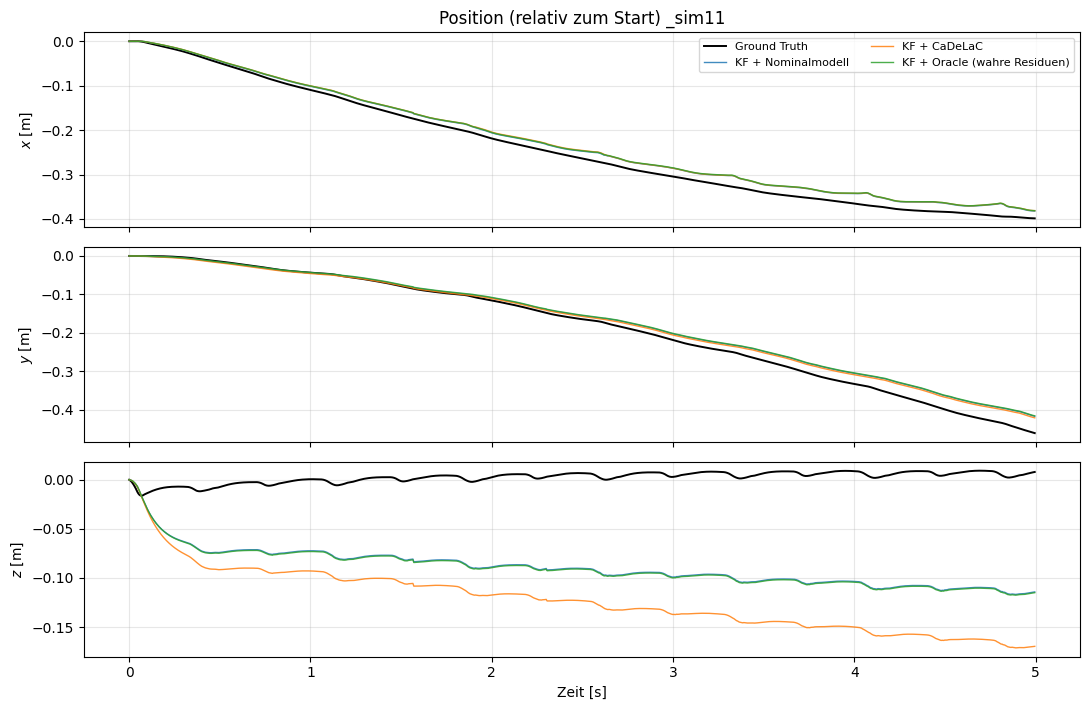

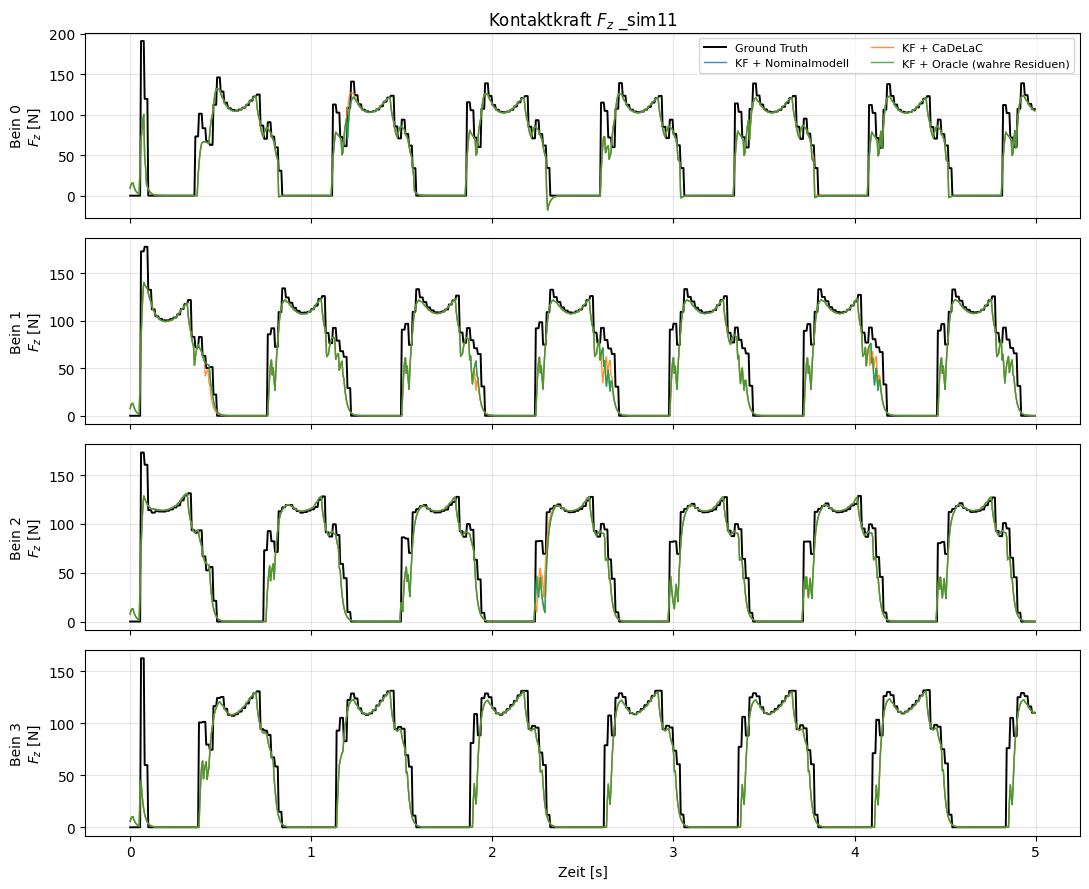

In [2]:
# Ein Lauf, alle Varianten: ein Plot pro Zustandsparameter (lin vel, ang vel, pos, Fz),
# jeweils Leg-Odometrie / KF+Nominal / KF+CaDeLaC / KF+Oracle gegen Ground Truth.
# Fuer den Report je einen repraesentativ guten und einen schlechten Lauf zeigen.
sim_num = 11   # Test-Lauf mit kleiner Nutzlast (0.142 kg) -- der schwierigste Fall
data_i = load_custom_dataset(dataset_path=dataset_path, sim_num=sim_num)

ladder = run_ladder_for_sim(data_i, cadelac_path)   # variants=("nominal","cadelac","oracle")
figs = plot_state_comparison(data_i, ladder, sim_label=f"_sim{sim_num}", save_dir=fig_dir)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


### Stufe: KF + Nominalmodell
Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.


Running state estimation:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1276.10it/s]


...

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run8.npz.


Running state estimation:   8%|▊         | 80/1000 [00:00<00:01, 793.62it/s]

Estimating contact state based on momentum
Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:00<00:00, 1197.13it/s]



Variante                        Split        vel RMSE x      vel RMSE y      vel RMSE z    ang vel RMSE       Pos-Drift         Fz RMSE
Leg-Odometrie (roh)             train            0.0468          0.0270          0.0801             nan             nan             nan
KF + Nominalmodell              train            0.0219          0.0232          0.1524          0.0331         20.2787         27.0919
KF + CaDeLaC                    train            0.0210          0.0173          0.2662          0.0291         26.6846         27.0639
KF + Oracle (wahre Residuen)    train            0.0217          0.0180          0.2484          0.0308         23.6339         27.0735
Leg-Odometrie (roh)             test             0.0448          0.0223          0.0756             nan             nan             nan
KF + Nominalmodell              test             0.0182          0.0209          0.1624          0.0305         18.4367         26.4238
KF + CaDeLaC                    test           

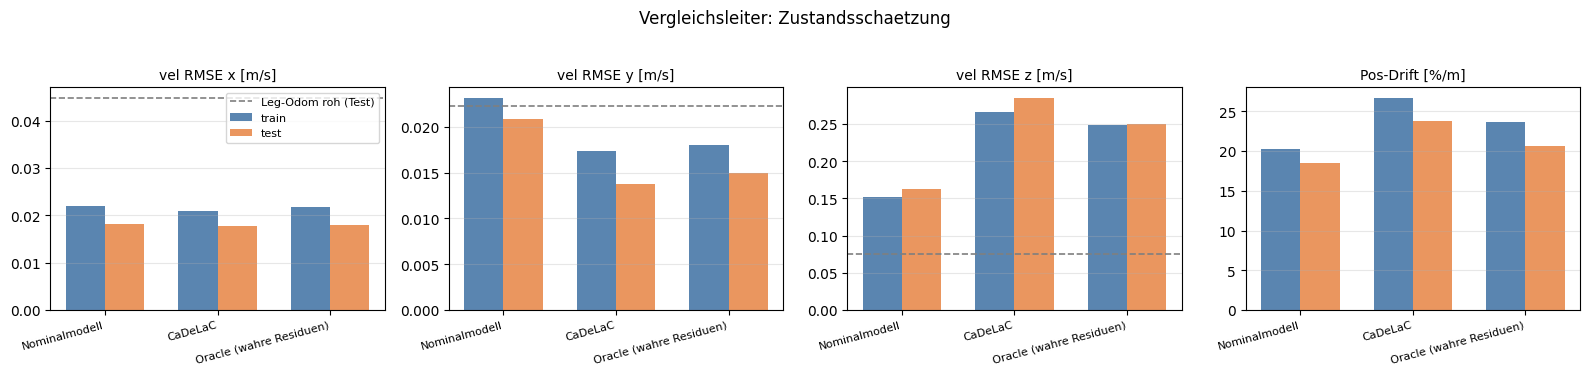

In [3]:
# Ganze Leiter ueber den Datensatz: rechnet den Filter 3x ueber alle Laeufe (dauert!).
# Fuer schnelle Iteration sim_nums=range(0, 50, 5) setzen, fuer den finalen Report None.
res_ladder = evaluate_ladder(dataset_path, cadelac_path, sim_nums=None, verbose=False)

summary = ladder_summary(res_ladder)              # Zahlen-Tabelle Train/Test fuer den Report
fig_bars = plot_ladder_bars(res_ladder, save_dir=fig_dir)

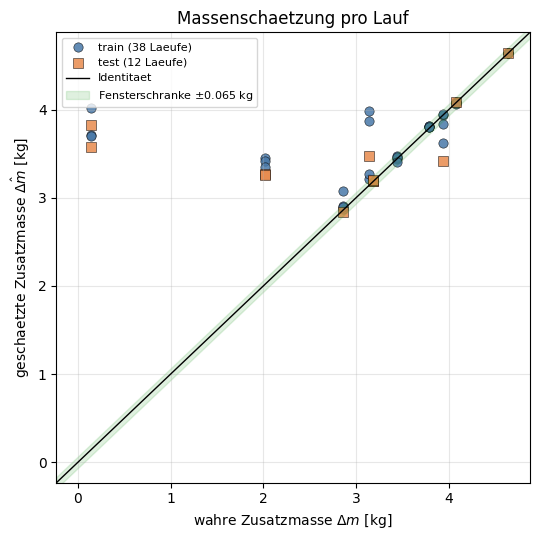

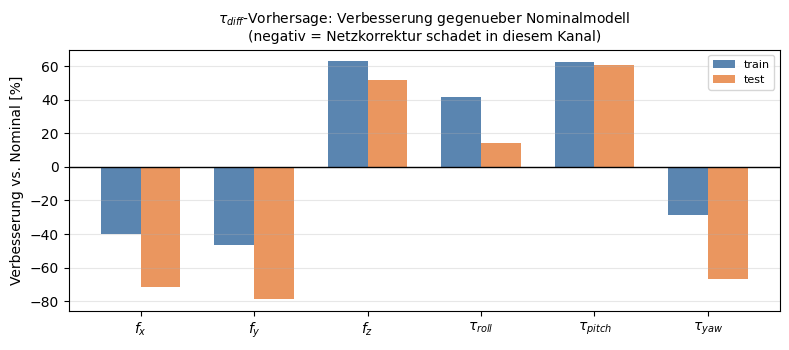

In [4]:
# Massen-Streudiagramm (wahr vs. geschaetzt pro Lauf, Train/Test) mit der physikalischen
# Fensterschranke aus check_inertia_predictions.py (500-ms-Fenster: ~0.065 kg), sowie
# tau_diff-Verbesserung pro Kanal gegenueber dem Nominalmodell (negativ = Netz schadet).
fig_scatter = plot_mass_scatter(res_ladder["cadelac"], bound_kg=0.065, save_dir=fig_dir)
fig_tau = plot_tau_improvement(res_ladder["cadelac"], save_dir=fig_dir)

In [5]:
# Volle Reports der einzelnen Stufen zum Nachlesen (Nominal/Oracle drucken nur Abschnitt 4)
from utils.evaluate import print_report

for variante, res in res_ladder.items():
    print_report(res)


Modell    : Nominalmodell (ohne CaDeLaC)
Datensatz : quad_mass_dataset_run8.npz   (50 Laeufe, est_mode 4)
Ground Truth an den Filter: keine (online-realistisch)

(kein CaDeLaC-Modell -- nur Filtermetriken)


4) KALMAN-FILTER -- Zustandsschaetzung gegen Ground Truth

 sim  split |         vel RMSE [m/s] |   ang vel RMSE [rad/s] |  Pos-Drift    je m
   0   test |  0.022  0.023  0.179    |  0.055  0.036  0.008    |      0.168  12.1%
   1   test |  0.011  0.015  0.093    |  0.043  0.019  0.009    |      0.121  16.8%
   2  train |  0.029  0.020  0.130    |  0.066  0.023  0.009    |      0.124  18.5%
   3   test |  0.010  0.015  0.092    |  0.045  0.019  0.009    |      0.142  21.5%
   4  train |  0.009  0.008  0.079    |  0.039  0.018  0.009    |      0.112  32.1%
   5  train |  0.025  0.021  0.142    |  0.056  0.029  0.009    |      0.156  11.6%
   6  train |  0.012  0.011  0.116    |  0.041  0.011  0.009    |      0.122  15.4%
   7  train |  0.027  0.020  0.103    |  0.046  0.020  0.010 